<a href="https://colab.research.google.com/github/voronv27/projects-in-ai-and-ml/blob/main/HW1/Homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Advanced Objective Function and Use Case

1. Derive the objective function for Logistic Regression using Maximum Likelihood
Estimation (MLE). Do some research on the MAP technique for Logistic Regression,
include your research on how this technique is different from MLE (include citations).

For a binary classification problem, the output will be one of two possible categories, i.e. 0/1. Linear regression provides continuous values, so to convert our outcome to a value between 0 and 1 for the classification problem, we use the sigmoid function.  

For input $x$, weights $w$, and output $y$, the linear model (from linear regression) is represented by the function \
$y = w^Tx$  

The sigmoid function,\
$\sigma(z) = \dfrac{1}{1+e^{-z}}$\
 will convert this continuous outcome from the linear model to a probability between 0 and 1. Our new predicted output $\hat{y}$ is:\
$\hat{y} = \sigma(w^T)$  

In the above function, the probability of 0/1 can be measured as:\
$P(y=1) = \sigma(w^Tx)$\
$P(y=0) = 1 - \sigma(w^Tx)$  
<br>

Under Maximum Likelihood Estimation, our goal is to choose parameters that will maximize a likelihood function. That is, we need to choose the weights $w$ that assign the highest probability to the data.  

So, we want to maximize our likelihood function $L(w)$ by solving $\hat{w} = \text{argmax}_{w}[L(w)]$.  

The likelihood function can be defined as:\
$L(w) = P(data|w) = P(y_1, x_1, y2, x_2, ..., y_n, x_n | w)$  

Assuming independent data,\
$P(y_1, x_1, y2, x_2, ..., y_n, x_n | w) = \Pi_{i=1}^n P(y_i, x_i | w) = \Pi_{i=1}^n P(y_i | x_i, w)P(x_i | w)= \Pi_{i=1}^n P(y_i | x_i, w)P(x_i | w) = \Pi_{i=1}^n P(y_i | x_i, w)P(x_i) = \Pi_{i=1}^n P(y_i | x_i, w)$  

<br>

Under a Bernoulli distribution, the PDF is\
$P(y_i | x_i, w) = p(x_i)^{y_i}(1-p(x_i))^{1-y_i}$,\
where $p(x_i) = P(y=1)$ (and $(1-p(x_i)) = P(y=0)$).  

Substituting in our sigmoid function gives us\
$P(y_i | x_i, w) = \sigma(w^Tx_i)^{y_i}(1-\sigma(w^Tx_i))^{1-y_i}$  

<br>

So, we would like to solve for $\hat{w}$ for\
$\hat{w} = \text{argmax}_{w}[\sum_{i=1}^{n} P(y_i | x_i, w)] =\text{argmax}_{w}[\Pi_{i=1}^n \sigma(w^Tx_i)^{y_i}(1-\sigma(w^Tx_i))^{1-y_i} ]$

<br>

We take the logarithm of the likelihood function to convert the product into a summation:
$\log(L(w)) = \log(\Pi_{i=1}^n \sigma(w^Tx_i)^{y_i}(1-\sigma(w^Tx_i))^{1-y_i}) = \sum_{i=1}^{n} y_i\log(\sigma(w^Tx_i)) + (1-y_i)\log(1-\sigma(w^Tx_i))$    

Maximizing this log-likelihood function $log(L(w))$ will give the same $w$ as maximizing $L(w)$ as the log function is monotonic.  


Finally, as optimization algorithms are designed to minimize functions, we want to rewrite our goal of maximizing the log-likelihood function into a loss function that should be minimized. We multiply by $-1$ as maximizing $L(x)$ is the same goal as minimizing $-L(x)$. We also multiply by $\frac{1}{n}$ to normalize the cost, so the cost/loss isn't impacted by number of data points.  

 This function is now known as the negative log-likelihood (NLL), and this is the objective function for logistic regression:\
$\hat{w} = \text{argmin}_{w}[-\dfrac{1}{n}\sum_{i=1}^{n} y_i\log(\sigma(w^Tx_i)) + (1-y_i)\log(1-\sigma(w^Tx_i))]$  

<br>

Note that if we want to include the bias parameter $b$ (which I excluded for readability), our equation would be:\
$\hat{w}, \hat{b} = \text{argmin}_{w,b}[-\dfrac{1}{n}\sum_{i=1}^{n} y_i\log(\sigma(w^Tx_i+b)) + (1-y_i)\log(1-\sigma(w^Tx_i+b))]$  


<br><br>

The MAP (Maximum a Posteriori) technique for logistic regression is different from MLE in that it has a prior distribution over $w$.  

In MLE, the goal is to maximize the likelihood $P(data|w)$, while in MAP, we want to maximize\
$P(w|data) \ \alpha \ P(data|w)P(data)$

MAP uses Bayes theorem to calculate the conditional probability of $P(w|data)$ as\
$P(w|data) = P(data|w)*P(w)$  
and $P(data | w)$ is derived by the MLE technique as shown above.

<br>

In the case where we assume a uniform prior, or equal likelihood for all values of $w$ (such as if we don't have prior information), both MLE and MAP will provide the same optimization problem.  

MAP is best used for problems where there is prior information so that the prior $w$ can be set to a good value, while MLE is better if there isn't such a prior.

Citations:

[1](https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/)
[2](https://zstevenwu.com/courses/s20/csci5525/resources/slides/lecture05.pdf)
[3](https://www.cs.cornell.edu/courses/cs4780/2015fa/web/lecturenotes/lecturenote06.html)
[4](https://machinelearningmastery.com/maximum-a-posteriori-estimation/)
[5](https://github.com/Uzmamushtaque/CSCI_4170_6170_Spring2026/blob/main/Lecture_01.ipynb)

2. Define a machine learning problem you wish to solve using Logistic Regression. Justify
why logistic regression is the best choice and compare it briefly to another linear
classification model (cite your work if this other technique was not covered in class).

I would like to solve email spam detection (spam/ham) using logistic regression. Logistic regression is a good fit for this problem because it is a classification problem--the model needs to classify each email into one of two categories: spam or ham. A logistic regression model is best for problems with a binary outcome, since it provides a probability estimate for each item belonging to a class (in this case, the probability of an email belonging to the spam (or ham) class).

We can compare logistic regression to SVM (Support Vector Machines) with a linear kernel, which is another linear classification model. Unlike logistic regression which provides a probability estimate, SVM creates a linear decision boundary to separate classes. Essentially, the goal is to minimize hinge loss by drawing a linear "line" across the data that cuts it into class A and class B (in this case, spam vs ham). Rather than saying that the email is 80% likely to be spam, an SVM model would just mark it as either spam or ham based on which side of the linear boundary it is on.  

 In the case of email, it's usually better for some spam mail to end up in the inbox than for important mail to be incorrectly marked as spam. SVM provides a binary yes/no for an email being spam, but doesn't give a level of confidence in its decision, meaning you can't see whether a "spam" email has an 99% probability of being spam, or 60% (whereas logistic regression does provide this probability estimate). Being able to judge an email based on probability of spam is more helpful for this problem, since we may want the spam "threshold" to err on the side of caution and only flag emails with a >90% chance of being spam (whereas with SVM we do not have a probability of spam at which the boundary is drawn).  

 Other benefits of logistic regression over SVM for this problem is that the model training time is faster than SVM and is easier to understand. So long as the classification capabilities/accuracy of the models are similar, choosing the simpler and faster-trained model is a better decision.

Citations:

[1](https://medium.com/@jwbtmf/multi-class-logistic-regression-vs-support-vector-machine-f6476675716d)
[2](https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/)

3. Discuss how your dataset corresponds to the variables in your equations, highlighting
any assumptions in your derivation from part 1.

In the proposed dataset, for an email $i$ we have features $x={x_1, x_2,...}$ based on the contents of the email (sender, keywords, links, etc) and outcome $y$, where $y=1$ is spam, and $y=0$ is ham.  

The weights $w={w_1,w_2,...}$ are the weights corresponding to each feature. We assume that the relationship between features $x$ and outcome $y$ is linear, and can be modeled based on the linear equation $y=x^Tx$.  

As such, we want to find the best weights $\hat{w}$ for the given $x$ (email features) and $y$ (whether the email is spam) in our data.  

The logistic regression equation derived in part 1 gives a method for finding the optimal weights $\hat{w}$:\
$\hat{w} = \text{argmin}_{w}[-\dfrac{1}{n}\sum_{i=1}^{n} y_i\log(\sigma(w^Tx_i)) + (1-y_i)\log(1-\sigma(w^Tx_i))]$\
where $n$ is the size of the dataset (number of emails).  

In order to use this equation, we must assume that the features of the email, $x$ are linearly independent--that is, the chosen features shouldn't depend on each other. We also assume that there is a linear relationship between our email features $x$ and outcome $y$.

# Task 2: Dataset and Advanced EDA

1.  Select a publicly available dataset (excluding commonly used datasets such as Titanic,
Housing Prices or Iris). Provide a link to your dataset. Ensure the dataset has at least 10
features to allow for more complex analysis.

I used this [Spotify Analysis Dataset 2025](https://www.kaggle.com/datasets/nabihazahid/spotify-dataset-for-churn-analysis). This dataset shows information about Spotify users and whether they churned or remained active on Spotify (0=active, 1=churned).

In [173]:
import pandas as pd

path = 'spotify.csv'

data = pd.read_csv(path)
data.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


2. Perform Exploratory Data Analysis (EDA), addressing potential multicollinearity among features. Use Variance Inflation Factor (VIF) to identify highly correlated variables and
demonstrate steps to handle them.

In [174]:
# Initial data inspection:
# first look at features, total number of entries,
# and check for missing values (none in this dataset)
print("(rows, columns):", data.shape)
data.info()

(rows, columns): (8000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


In our dataset, there are no missing values, so we do not need to ignore any columns or replace any values due to null values. Otherwise we would have to impute and/or delete some of our data.

In [175]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# separate features (x) from label (y)
label_col = "is_churned"
assert label_col in data.columns, f"Label column {label_col} not in data"

x = data.drop(columns=[label_col, "user_id"]) #drop user_id--this is just an identifier and isn't going to predict if a user stays
y = data[label_col]

# skip imputing missing values as there are none
# scale values
num_cols = [c for c in x.columns if x[c].dtype != 'object']
numerical_tf = Pipeline(steps=[
    ("scale", StandardScaler())
])

# one-hot encode categorical columns
# set sparse_output=False for calculating VIF
cat_cols = [c for c in x.columns if x[c].dtype == 'object']
categorical_tf = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop='first', sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_tf, num_cols),
        ("cat", categorical_tf, cat_cols)
    ]
)

# Get our transformed features and convert back to pandas dataframe
x_transformed = preprocess.fit_transform(x)
feature_names = preprocess.get_feature_names_out()
vif_data = pd.DataFrame(x_transformed, columns=feature_names)
vif_data = add_constant(vif_data)

# Calculate and display VIF per feature
vif_results = pd.DataFrame()
vif_results["feature"] = vif_data.columns
vif_results["VIF"] = [variance_inflation_factor(vif_data, i)
                      for i in range(vif_data.shape[1])]
print(vif_results.sort_values("VIF", ascending=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                           feature       VIF
6           num__offline_listening       inf
16     cat__subscription_type_Free       inf
5       num__ads_listened_per_week  4.372995
15                 cat__country_US  1.742739
10                 cat__country_DE  1.733155
12                 cat__country_IN  1.731877
13                 cat__country_PK  1.725089
11                 cat__country_FR  1.716354
14                 cat__country_UK  1.703224
9                  cat__country_CA  1.696387
17  cat__subscription_type_Premium  1.555609
18  cat__subscription_type_Student  1.532224
7                 cat__gender_Male  1.339173
8                cat__gender_Other  1.338748
19         cat__device_type_Mobile  1.311176
20            cat__device_type_Web  1.309642
4                   num__skip_rate  1.003130
3        num__songs_played_per_day  1.003064
2              num__listening_time  1.002384
1                         num__age  1.002212
0                            const  0.000000


We see that num__offline__listening and cat__subscription__type_Free have a very high correlation (VIF=infinity). We can compare the two with pd.crosstab() and see that this is because on the Free plan, there is no offline listening:

In [176]:

print(pd.crosstab(data['offline_listening'], data['subscription_type']))

subscription_type  Family  Free  Premium  Student
offline_listening                                
0                       0  2018        0        0
1                    1908     0     2115     1959


As such, we keep the subscription_type column which contains the Free plan, but delete the offline_listening column from our data:

In [177]:
x = data.drop(columns=[label_col, "user_id", "offline_listening"]) #drop user_id--this is just an identifier and isn't going to predict if a user stays
y = data[label_col]

# skip imputing missing values as there are none
# scale values
num_cols = [c for c in x.columns if x[c].dtype != 'object']
numerical_tf = Pipeline(steps=[
    ("scale", StandardScaler())
])

# one-hot encode categorical columns
# set sparse_output=False for calculating VIF
cat_cols = [c for c in x.columns if x[c].dtype == 'object']
categorical_tf = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop='first', sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_tf, num_cols),
        ("cat", categorical_tf, cat_cols)
    ]
)

# Get our transformed features and convert back to pandas dataframe
x_transformed = preprocess.fit_transform(x)
feature_names = preprocess.get_feature_names_out()
vif_data = pd.DataFrame(x_transformed, columns=feature_names)
vif_data = add_constant(vif_data)

# Calculate and display VIF per feature
vif_results = pd.DataFrame()
vif_results["feature"] = vif_data.columns
vif_results["VIF"] = [variance_inflation_factor(vif_data, i)
                      for i in range(vif_data.shape[1])]
print(vif_results.sort_values("VIF", ascending=False))

                           feature        VIF
0                            const  15.619988
15     cat__subscription_type_Free   4.916199
5       num__ads_listened_per_week   4.372995
14                 cat__country_US   1.742739
9                  cat__country_DE   1.733155
11                 cat__country_IN   1.731877
12                 cat__country_PK   1.725089
10                 cat__country_FR   1.716354
13                 cat__country_UK   1.703224
8                  cat__country_CA   1.696387
16  cat__subscription_type_Premium   1.555609
17  cat__subscription_type_Student   1.532224
6                 cat__gender_Male   1.339173
7                cat__gender_Other   1.338748
18         cat__device_type_Mobile   1.311176
19            cat__device_type_Web   1.309642
4                   num__skip_rate   1.003130
3        num__songs_played_per_day   1.003064
2              num__listening_time   1.002384
1                         num__age   1.002212


These VIF values are all under 5 (outside of const, which is just the constant), meaning that there isn't high correlation and they're safe to use together in our model.

3. Visualize the dataset's feature relationships, ensuring inclusion of at least two advanced
visualization techniques (e.g., pair plots with KDE, heatmaps with clustering).

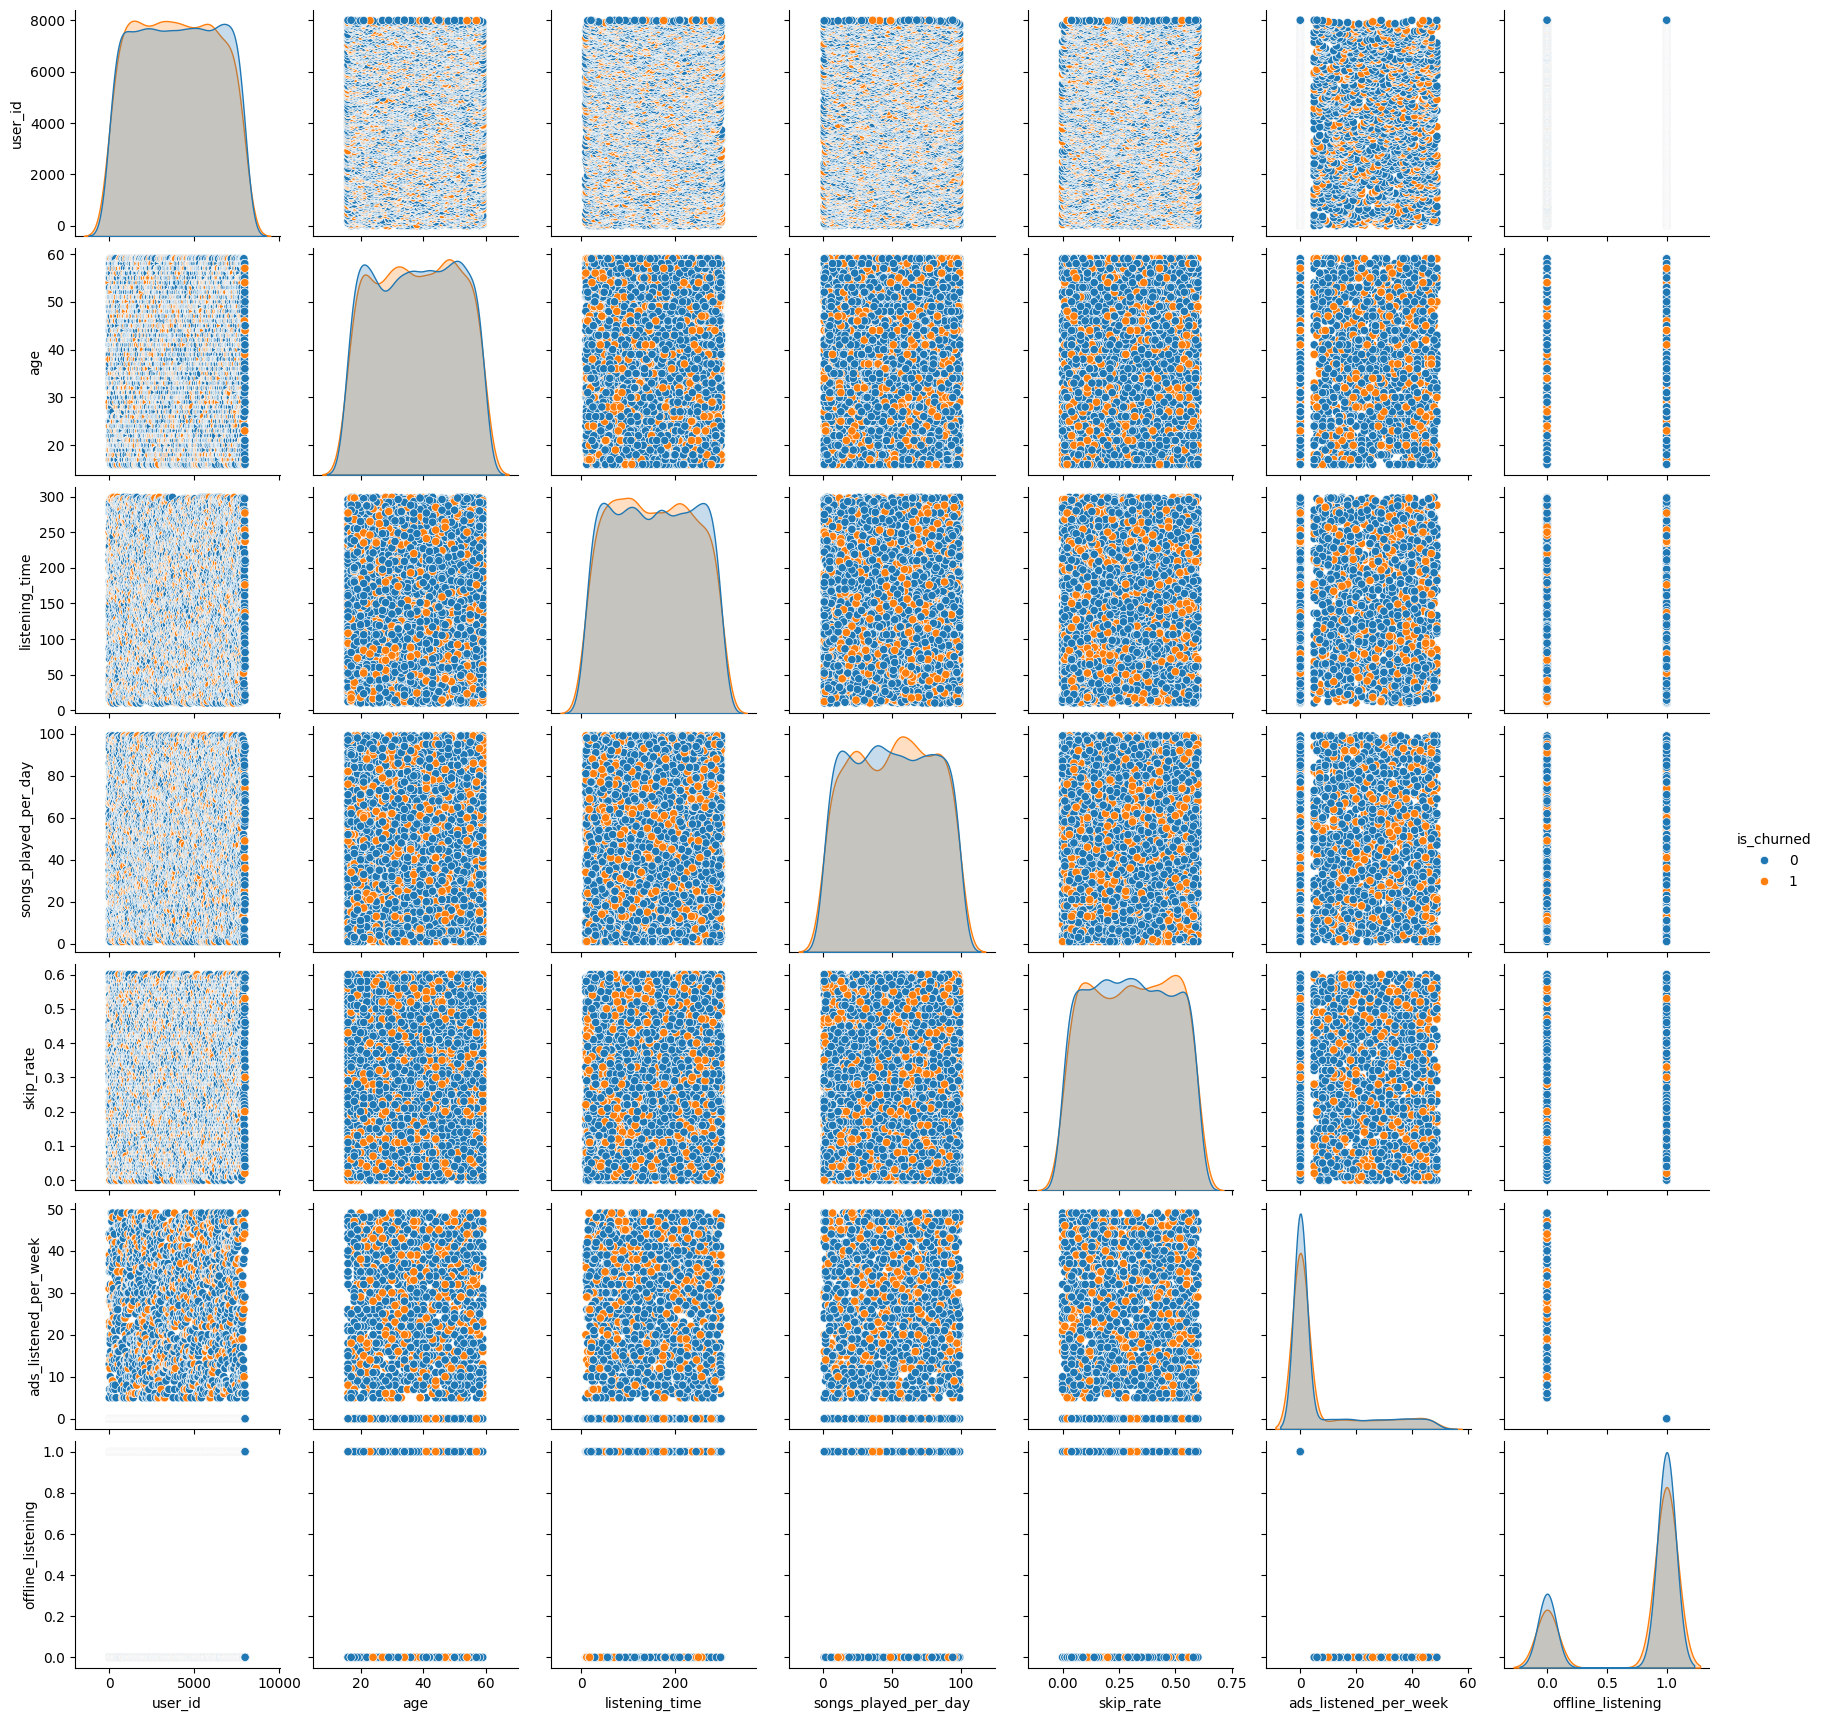

In [178]:
import seaborn as sns
import matplotlib.pyplot as plt

# create pair plots with KDE
# original data
sns.pairplot(
    data,
    hue='is_churned',
    diag_kind='kde',
    diag_kws={'common_norm': False}
)

Here we can again see that there was high correlation for offline_listening, as visible from the linear patterns on the non-diagonal plots for offline_listening. In comparison, the other data points are independent and are plotted fairly randomly. The plots along the diagonal can give us information on each singular feature (they have been normalized to account for uneven churn/remain active values). For example, we can see that the majority of users (both churn and active) in this dataset listen to a small amount of ads. At this point, and there is also greater retention (less churn). As the number of ads goes up, the number of users who churn becomes equal with the users who don't churn, or churn relatively increases with the number of ads (though the number of users listening to ads is lower on both churned/active users).

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


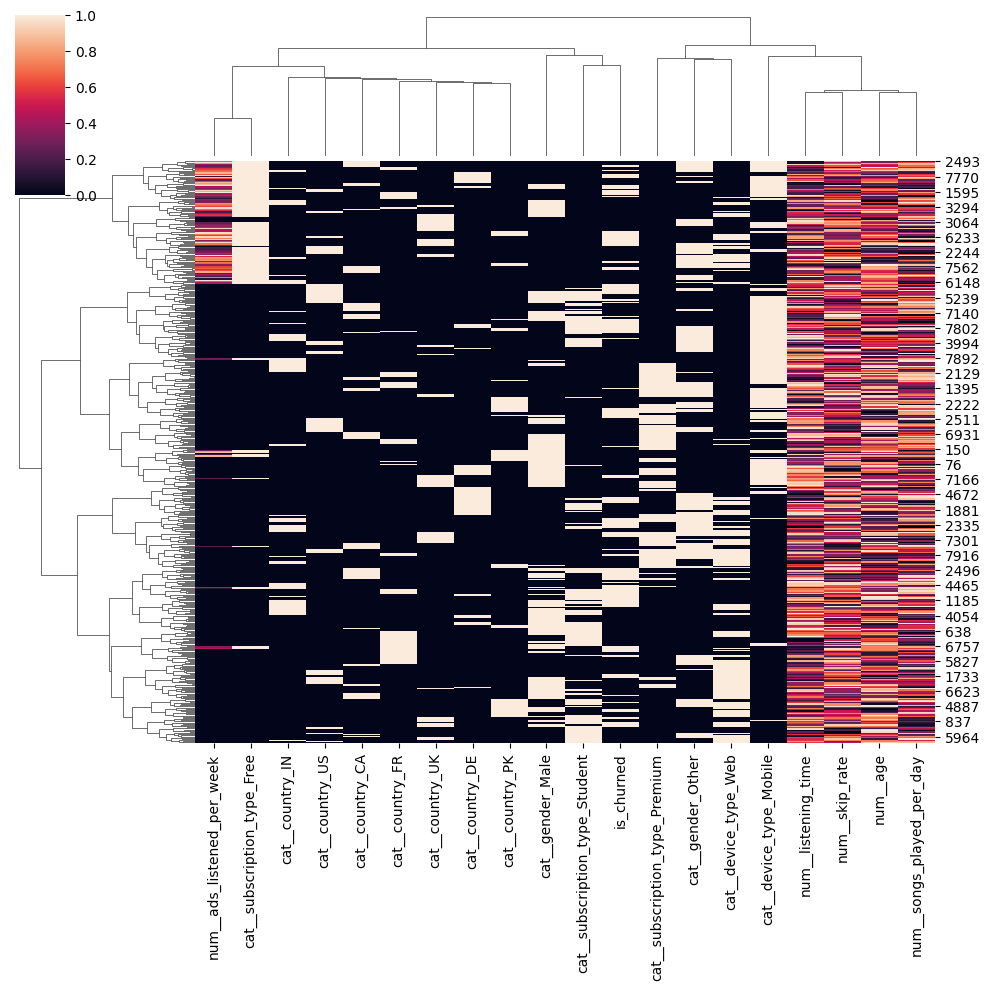

In [181]:
import seaborn as sns
import matplotlib.pyplot as plt

# cluster map
# take a sample of the data to speed up the clustermap
x_data = vif_data.drop(columns=['const'])
data_with_label = pd.concat([x_data, y], axis=1)
samp = data_with_label.sample(500)

sns.clustermap(
    samp,
    standard_scale=1,
    method='ward'
)

plt.show()

The trees let us see what features are similar (on the top tree), and groups users (on the left tree). The shortest branch we have on top is between ads played and the free subscription type, which makes sense, since only Spotify users on the free plan are listening to ads. Of course, the VIF calculation is still moderate correlation, perhaps because the number of ads also depends on how much the user is using Spotify.  

On the left hand side, we can see how the users have been split into "categories" by the row dendrogram. The first split lines up with the heat map in the free subscription type column. That is, in the subscription type column, there are two main "chunks" of color, and they line up with where the first branch on the tree split the users. So, the first way that different types of users were categorized was by whether they were using the free plan or a paid plan. (Which makes sense--whether a user is willing to pay for Spotify will change how they use the app, from being able to skip more songs, to listening ad-free).  

The colors on the heatmap represent a scale of lowest to highest value. We see extreme 0 and 1 for categories which have been mapped to 0 and 1s only, while numerical categories can be in the middle. Looking across a column and comparing it to other columns shows where values across features are related. For example, we can see that higher ads lines up with users with the Free plan.

# Task 3: Logistic Regression Implementation

1. Implement Logistic Regression from scratch, including the vectorized implementation of
cost function and gradient descent.

In [201]:
from sklearn.model_selection import train_test_split
import numpy as np

x_train, x_test, y_train, y_test = train_test_split(
    x_transformed, y, test_size=0.2, random_state=42, stratify=y
)

# sigmoid function
def sig(z):
  return 1 / (1 + np.exp(-z))

# consts & initial values
n,d = x_train.shape
w = np.zeros(d)
b = 0
lr = 0.01
steps = 600
eps = 1e-12

for t in range(steps):
  # calculate loss function
  z = x_train @ w + b
  a = sig(z)
  loss = -(y_train * np.log(a + eps) + (1 - y_train) * np.log(1 - a + eps)).mean()

  # gradients
  dz = a - y_train
  dw = x_train.T @ dz / n
  db = dz.mean()

  # update w and b in direction of gradient * learning rate
  w -= lr * dw
  b -= lr * db

  if t % 50 == 0:
    print(f"step: {t}, loss: {loss:.4f}")

# evaluate accuracy
test_probs = sig(x_test @ w + b)
test_preds = (test_probs >= 0.5).astype(int)
acc = (test_preds == y_test).mean()
print("Test accuracy:", round(float(acc), 4))

# store for task 4 (see task 4 for why this is 0.3)
test_preds = (test_probs >= 0.3).astype(int)
test_preds_batch = test_preds


step: 0, loss: 0.6931
step: 50, loss: 0.6519
step: 100, loss: 0.6253
step: 150, loss: 0.6080
step: 200, loss: 0.5967
step: 250, loss: 0.5891
step: 300, loss: 0.5840
step: 350, loss: 0.5805
step: 400, loss: 0.5781
step: 450, loss: 0.5765
step: 500, loss: 0.5753
step: 550, loss: 0.5745
Test accuracy: 0.7412


2. Implement and compare the three gradient descent variants (e.g., batch gradient
descent, stochastic gradient descent, and mini-batch gradient descent). Explain their
convergence properties with respect to your cost function.

In [202]:
# Batch gradient descent was implemented above

# Stochastic gradient descent
# reset values
w = np.zeros(d)
b = 0
lr = 0.01
steps = 50 #lower amount because we update n times per step

# convert y_train to numpy arrays for indexing
y_train_np = y_train.values

for t in range(steps):
  # shuffle data
  shuffle = np.random.permutation(n)
  x_train_shuffle = x_train[shuffle]
  y_train_shuffle = y_train_np[shuffle]

  # for each data point, update w and b
  for i in range(n):
    xi = x_train_shuffle[i]
    yi = y_train_shuffle[i]

    zi = xi @ w + b
    ai = sig(zi)

    # gradients
    dz = ai - yi
    dw = xi * dz
    db = dz

    # update w and b in direction of gradient * learning rate
    w -= lr * dw
    b -= lr * db

  # calculate loss function using the correctly shuffled y_train
  z = x_train_shuffle @ w + b
  a = sig(z)
  loss = -(y_train_shuffle * np.log(a + eps) + (1 - y_train_shuffle) * np.log(1 - a + eps)).mean()


  if t % 10 == 0:
    print(f"step: {t}, loss: {loss:.4f}")

# evaluate
test_probs = sig(x_test @ w + b)
test_preds = (test_probs >= 0.5).astype(int)
acc = (test_preds == y_test_np).mean() # Use y_test_np for evaluation
print("Test accuracy:", round(float(acc), 4))

# store for task 4
test_preds = (test_probs >= 0.3).astype(int)
test_preds_stochastic = test_preds

step: 0, loss: 0.5718
step: 10, loss: 0.5798
step: 20, loss: 0.5727
step: 30, loss: 0.5728
step: 40, loss: 0.5722
Test accuracy: 0.7412


In [203]:
# Minibatch gradient descent
# reset values
w = np.zeros(d)
b = 0
steps = 50

for t in range(steps):
  # shuffle data
  shuffle = np.random.permutation(n)
  x_train_shuffle = x_train[shuffle]
  y_train_shuffle = y_train_np[shuffle]

  # for each mini batch of data (size 50), update w and b
  for i in range(0, n, 50):
    xi = x_train_shuffle[i:i+50]
    yi = y_train_shuffle[i:i+50]

    zi = xi @ w + b
    ai = sig(zi)

    # gradients
    dz = ai - yi
    dw = xi.T @ dz / 50
    db = dz.mean()

    # update w and b in direction of gradient * learning rate
    w -= lr * dw
    b -= lr * db

  # calculate loss function
  z = x_train_shuffle @ w + b
  a = sig(z)
  loss = -(y_train_shuffle * np.log(a + eps) + (1 - y_train_shuffle) * np.log(1 - a + eps)).mean()

  if t % 10 == 0:
    print(f"step: {t}, loss: {loss:.4f}")

# evaluate
test_probs = sig(x_test @ w + b)
test_preds = (test_probs >= 0.5).astype(int)
acc = (test_preds == y_test).mean()
print("Test accuracy:", round(float(acc), 4))

# store for task 4
test_preds = (test_probs >= 0.3).astype(int)
test_preds_minibatch = test_preds

step: 0, loss: 0.6145
step: 10, loss: 0.5720
step: 20, loss: 0.5714
step: 30, loss: 0.5710
step: 40, loss: 0.5708
Test accuracy: 0.7412


# Task 4: Optimization Techniques and Advanced Comparison

1. Implement or use packages to incorporate any three optimization algorithms (e.g.,
Momentum, RMSProp, Adam). Compare their performance with the vanilla stochastic
gradient descent implementation from Task 3.

In [208]:
import tensorflow as tf

# Momentum (Used with Batch Gradient Descent)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    x_train, y_train,
    batch_size=n,
    epochs=100
)

# store for task 4
test_probs = model.predict(x_test)
test_preds = (test_probs >= 0.3).astype(int)
test_preds_momentum = test_preds

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step - accuracy: 0.4833 - loss: 0.7830
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4844 - loss: 0.7816
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4864 - loss: 0.7791
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.4884 - loss: 0.7754
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.4914 - loss: 0.7709
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4961 - loss: 0.7656
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.5019 - loss: 0.7596
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5072 - loss: 0.7532
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5139 - loss: 0.7463
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5208 - loss: 0.7392
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.5269 - loss: 0.7319
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.53

Batch gradient descent with Momentum got about the same accuracy as the vanilla version of stochastic (as well as batch and mini-batch) gradient descent, and it ran in less epochs than batch gradient descent.

I tried Momentum with Stochastic gradient descent, but it took a long time to run for even a small amount of epochs. It seems this method is better used for batch/mini-batch, or a smaller data set, since it takes more computation per iteration. However, it can also run faster since it converges faster. Momentum is good for noisy data where regular gradient descent may jump around a lot, since it dampens the oscillations in the model.

In [209]:
# RMSprop
optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr, rho=0.9)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.fit(
    x_train, y_train,
    batch_size=n,
    epochs=50
)

# store for task 4
test_probs = model.predict(x_test)
test_preds = (test_probs >= 0.3).astype(int)
test_preds_rmsprop = test_preds

rmsprop_model = model

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 868ms/step - accuracy: 0.5920 - loss: 0.6892
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6223 - loss: 0.6614
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6372 - loss: 0.6455
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6516 - loss: 0.6345
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.6650 - loss: 0.6262
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6795 - loss: 0.6196
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.6853 - loss: 0.6143
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.6942 - loss: 0.6099
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7008 - loss: 0.6062
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.7059 - loss: 0.6030
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.7120 - loss: 0.6003
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7164 - los

RMSprop (Root Mean Square Propagation) adapts the learning rate by keeping an average of the squares of past gradients. The goal is to speed up the number of iterations it takes to fit the data, like Momentum. For this dataset, RMSprop performed very well, matching vanilla batch gradient descent's accuracy in significantly less epochs. When I tried it for Stochastic GD instead of Batch GD, it was a lot slower in runtime than vanilla, however this is not an entirely fair comparison, as I believe this extra runtime is also due to using a module for these optimizations as opposed to the cleaner, more barebones, "from scratch" version. In terms of iteration count, it is clearly faster, though it is also more complex.

In [210]:
# Adam
optimizer = tf.keras.optimizers.Adam(learning_rate=lr, beta_1=0.9, beta_2=0.9)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.fit(
    x_train, y_train,
    batch_size=n,
    epochs=70
)

# store for task 4
test_probs = model.predict(x_test)
test_preds = (test_probs >= 0.3).astype(int)
test_preds_adam = test_preds

adam_model = model

Epoch 1/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 947ms/step - accuracy: 0.4708 - loss: 0.8063
Epoch 2/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.4778 - loss: 0.7928
Epoch 3/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.4858 - loss: 0.7797
Epoch 4/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.4959 - loss: 0.7670
Epoch 5/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5072 - loss: 0.7548
Epoch 6/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5161 - loss: 0.7430
Epoch 7/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5283 - loss: 0.7317
Epoch 8/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5394 - loss: 0.7208
Epoch 9/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5491 - loss: 0.7104
Epoch 10/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5589 - loss: 0.7004
Epoch 11/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.5700 - loss: 0.6909
Epoch 12/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5781 - loss: 0

The final optimization algorithm I implemented was Adam (Adaptive Moment Estimation), which combines Momentum and RMSprop. I saw the accuracy "bounce" a bit with this model, but not significantly. Like Momentum and RMSprop, it ran in significantly less epochs than vanilla Batch GD, but was slow to run for Stochastic GD.

2. Define and use multiple evaluation metrics (e.g., precision, recall, F1 score) to analyze
and interpret results for each algorithm.

I will evaluate my results by precision, recall, and F1 score.

In [207]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Batch Gradient Descent:")
print("Precision:", precision_score(y_test, test_preds_batch))
print("Recall:", recall_score(y_test, test_preds_batch))
print("F1 Score:", f1_score(y_test, test_preds_batch))

print("\nStochastic Gradient Descent:")
print("Precision:", precision_score(y_test, test_preds_stochastic))
print("Recall:", recall_score(y_test, test_preds_stochastic))
print("F1 Score:", f1_score(y_test, test_preds_stochastic))

print("\nMinibatch Gradient Descent:")
print("Precision:", precision_score(y_test, test_preds_minibatch))
print("Recall:", recall_score(y_test, test_preds_minibatch))
print("F1 Score:", f1_score(y_test, test_preds_minibatch))

print("\nMomentum:")
print("Precision:", precision_score(y_test, test_preds_momentum))
print("Recall:", recall_score(y_test, test_preds_momentum))
print("F1 Score:", f1_score(y_test, test_preds_momentum))

print("\nRMSprop:")
print("Precision:", precision_score(y_test, test_preds_rmsprop))
print("Recall:", recall_score(y_test, test_preds_rmsprop))
print("F1 Score:", f1_score(y_test, test_preds_rmsprop))

print("\nAdam:")
print("Precision:", precision_score(y_test, test_preds_adam))
print("Recall:", recall_score(y_test, test_preds_adam))
print("F1 Score:", f1_score(y_test, test_preds_adam))

Batch Gradient Descent:
Precision: 0.2505263157894737
Recall: 0.28743961352657005
F1 Score: 0.2677165354330709

Stochastic Gradient Descent:
Precision: 0.23770491803278687
Recall: 0.14009661835748793
F1 Score: 0.1762917933130699

Minibatch Gradient Descent:
Precision: 0.24031007751937986
Recall: 0.0748792270531401
F1 Score: 0.1141804788213628

Momentum:
Precision: 0.2727272727272727
Recall: 0.2826086956521739
F1 Score: 0.2775800711743772

RMSprop:
Precision: 0.25048923679060664
Recall: 0.30917874396135264
F1 Score: 0.27675675675675676

Adam:
Precision: 0.26778242677824265
Recall: 0.30917874396135264
F1 Score: 0.28699551569506726


These scores are pretty bad. As I found out when I used my original test_preds, all the predictions were 0. Due to my data having more 0s than 1s for the label is_churned, the model defaulted to just predicting 0 for all cases. I tried adjusting the data by duplicating the data values for is_churned=1, but this decreased the accuracy of the model by a signficant amount. Another method that could have helped would be to change the loss function to weight 1s in the data more heavily. However, I wasn't sure if this would stray away from the point of implementing vanilla gradient descent with the loss formula I derived in task 1 (and which we have discussed in class), so I decided against doing this. In the end, I decided to leave my original data and model and document my mistake here. For some non-zero predictions that could be used for my precision, recall, and F1 scores, I compared the model predictions against a probability of 0.3 (so >=0.3 was considered 1).

Of all the algorithms, the model with the best precision was Momentum, the model with the best recall was tied between Adam and RMSProp, and the highest F1 score (best combined precision and recall) was for Adam.

3. Perform a hyperparameter tuning process (manual or automated using grid
search/random search) for each optimization algorithm and assess its impact on
performance. If you have to do some research for these techniques, please cite your
sources.

In [222]:
# Use random search
# Momentum
learning_rates = [0.5, 0.1, 0.01, 0.001]
momentum = [1, 0.95, 0.9, 0.8, 0.5]
epochs = [30, 50, 80, 100, 150]
results = []

for i in range(10):
  # randomly pick parameters
  lr = np.random.choice(learning_rates)
  mom = np.random.choice(momentum)
  ep = np.random.choice(epochs)
  optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=mom)

  model = tf.keras.Sequential([
      tf.keras.layers.Input(shape=(x_train.shape[1],)),
      tf.keras.layers.Dense(1, activation='sigmoid')
  ])
  model.compile(
      optimizer=optimizer,
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  model.fit(
      x_train, y_train,
      batch_size=n,
      epochs=ep,
      verbose=False
  )

  loss, acc = model.evaluate(x_test, y_test, verbose=False)
  results.append((lr, mom, ep, loss, acc))
  print(f"lr: {lr}, momentum: {mom}, loss: {loss}, accuracy: {acc}")

best_params = min(results, key=lambda x: x[3])
lr, mom, ep, loss, acc = best_params
print()
print(f"Best parameters: lr: {lr}, momentum: {mom}, ep: {ep}, loss: {loss}, accuracy: {acc}")

lr: 0.5, momentum: 1.0, loss: 0.6596064567565918, accuracy: 0.6706249713897705
lr: 0.01, momentum: 0.9, loss: 0.587496817111969, accuracy: 0.7412499785423279
lr: 0.1, momentum: 0.9, loss: 0.5732294321060181, accuracy: 0.7412499785423279
lr: 0.001, momentum: 0.9, loss: 0.642380952835083, accuracy: 0.6412500143051147
lr: 0.1, momentum: 1.0, loss: 0.7658458948135376, accuracy: 0.5450000166893005
lr: 0.5, momentum: 0.8, loss: 0.5749706625938416, accuracy: 0.7412499785423279
lr: 0.01, momentum: 0.95, loss: 0.5910197496414185, accuracy: 0.7412499785423279
lr: 0.1, momentum: 0.9, loss: 0.5752052068710327, accuracy: 0.7412499785423279
lr: 0.01, momentum: 0.8, loss: 0.5961880683898926, accuracy: 0.7275000214576721
lr: 0.01, momentum: 0.8, loss: 0.6584346890449524, accuracy: 0.609375

Best parameters: lr: 0.1, momentum: 0.9, ep: 100, loss: 0.5732294321060181, accuracy: 0.7412499785423279


In [220]:
# Use random search
# RMSProp
learning_rates = [0.5, 0.1, 0.01, 0.001]
rhos = [1, 0.95, 0.9, 0.8, 0.5]
epochs = [10, 30, 50, 80, 100]
results = []

for i in range(10):
  # randomly pick parameters
  lr = np.random.choice(learning_rates)
  rho = np.random.choice(rhos)
  ep = np.random.choice(epochs)
  optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr, rho=rho)

  model = tf.keras.Sequential([
      tf.keras.layers.Input(shape=(x_train.shape[1],)),
      tf.keras.layers.Dense(1, activation='sigmoid')
  ])
  model.compile(
      optimizer=optimizer,
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  model.fit(
      x_train, y_train,
      batch_size=n,
      epochs=ep,
      verbose=False
  )

  loss, acc = model.evaluate(x_test, y_test, verbose=False)
  results.append((lr, rho, ep, loss, acc))
  print(f"lr: {lr}, rho: {rho}, loss: {loss}, accuracy: {acc}")

best_params = min(results, key=lambda x: x[3])
lr, rho, ep, loss, acc = best_params
print()
print(f"Best parameters: lr: {lr}, rho: {rho}, ep: {ep}, loss: {loss}, accuracy: {acc}")

lr: 0.5, rho: 0.9, loss: 0.6649601459503174, accuracy: 0.7387499809265137
lr: 0.001, rho: 0.5, loss: 0.6669719219207764, accuracy: 0.5943750143051147
lr: 0.01, rho: 0.95, loss: 0.5921140909194946, accuracy: 0.7362499833106995
lr: 0.5, rho: 0.5, loss: 0.5978255271911621, accuracy: 0.7362499833106995
lr: 0.1, rho: 0.8, loss: 0.5801349878311157, accuracy: 0.7412499785423279
lr: 0.01, rho: 0.8, loss: 0.5732313990592957, accuracy: 0.7412499785423279
lr: 0.5, rho: 0.95, loss: 0.6320664882659912, accuracy: 0.6693750023841858
lr: 0.01, rho: 0.8, loss: 0.5736557245254517, accuracy: 0.7412499785423279
lr: 0.1, rho: 1.0, loss: 37.44689178466797, accuracy: 0.7412499785423279
lr: 0.1, rho: 0.9, loss: 0.5804040431976318, accuracy: 0.7412499785423279

Best parameters: lr: 0.01, rho: 0.8, ep: 100, loss: 0.5732313990592957, accuracy: 0.7412499785423279


In [221]:
# Use random search
# Adam
learning_rates = [0.5, 0.1, 0.01, 0.001]
betas = [1, 0.95, 0.9, 0.8, 0.5]
epochs = [10, 30, 50, 80, 100]
results = []

for i in range(10):
  # randomly pick parameters
  lr = np.random.choice(learning_rates)
  b1 = np.random.choice(betas)
  b2 = np.random.choice(betas)
  ep = np.random.choice(epochs)
  optimizer = tf.keras.optimizers.Adam(learning_rate=lr, beta_1=b1, beta_2=b2)

  model = tf.keras.Sequential([
      tf.keras.layers.Input(shape=(x_train.shape[1],)),
      tf.keras.layers.Dense(1, activation='sigmoid')
  ])
  model.compile(
      optimizer=optimizer,
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  model.fit(
      x_train, y_train,
      batch_size=n,
      epochs=ep,
      verbose=False
  )

  loss, acc = model.evaluate(x_test, y_test, verbose=False)
  results.append((lr, b1, b2, ep, loss, acc))
  print(f"lr: {lr}, beta_1: {b1}, beta_2: {b2}, loss: {loss}, accuracy: {acc}")

best_params = min(results, key=lambda x: x[4])
lr, b1, b2, ep, loss, acc = best_params
print()
print(f"Best parameters: lr: {lr}, beta_1: {b1}, beta_2: {b2}, ep: {ep}, loss: {loss}, accuracy: {acc}")

lr: 0.5, beta_1: 0.5, beta_2: 0.9, loss: 0.5764665007591248, accuracy: 0.7412499785423279
lr: 0.5, beta_1: 0.95, beta_2: 0.9, loss: 0.572360634803772, accuracy: 0.7412499785423279
lr: 0.5, beta_1: 0.5, beta_2: 0.8, loss: 0.5728791952133179, accuracy: 0.7412499785423279
lr: 0.5, beta_1: 1.0, beta_2: 0.95, loss: nan, accuracy: 0.7412499785423279
lr: 0.1, beta_1: 0.9, beta_2: 1.0, loss: 0.672159731388092, accuracy: 0.5993750095367432
lr: 0.5, beta_1: 0.8, beta_2: 0.95, loss: 0.5982300043106079, accuracy: 0.7412499785423279
lr: 0.001, beta_1: 0.95, beta_2: 0.9, loss: 0.6914447546005249, accuracy: 0.5687500238418579
lr: 0.001, beta_1: 0.5, beta_2: 0.95, loss: 0.7380297183990479, accuracy: 0.5224999785423279
lr: 0.1, beta_1: 0.8, beta_2: 1.0, loss: 0.7804607152938843, accuracy: 0.5256249904632568
lr: 0.5, beta_1: 0.8, beta_2: 1.0, loss: 0.6255215406417847, accuracy: 0.6618750095367432

Best parameters: lr: 0.5, beta_1: 0.95, beta_2: 0.9, ep: 80, loss: 0.572360634803772, accuracy: 0.741249978

I used random search to tune my hyperparameters, trying out a variety of parameter combinations and outputting the parameters that gave the best result at the end. I kept the examples small with 10 iterations per optimization model.

According to my research, randomly-chosen trials are more efficient for hyper-parameter optimization, which I found interesting. It makes sense, since grid search is exhaustive, and manual tuning introduces human bias on what we think would be tweaked.

Citations:
[1](https://dl.acm.org/doi/10.5555/2188385.2188395)

4. Conclude by discussing the practical trade-offs of the algorithms, including
computational complexity, interpretability, and suitability for large-scale datasets.

Different algorithms all have their place in machine learning. Certain algorithms are simple to implement (such as the vanilla gradient descent I implemented in task 3) but may take more iterations to settle on "good" weights than a more complex model with optimization built into it. On the other hand, a more complex model requires more computational complexity per iteration, so while the number of iterations required decreases, the runtime and resources required may not.

In addition, it can be more difficult to understand what the model is doing and know what paraters can be tuned for better performance, meaning some interpretability is lost.

For large-scale datasets, the benefits of less iterations are clear, and the more complex optimizations are worth it. On the other hand, for small datasets, sticking to something simpler may result in better performance and understandability.

(And no matter the algorithm, it's also important to clean up the data before you start, so you don't end up with poor precision and recall scores like I did due to my uneven churn to stay ratio.)